In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

batch_size = 128
z_dim = 100
num_epochs = 20
lr = 2e-4
beta1 = 0.5
num_workers = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=torch.cuda.is_available()
)

print("Training samples:", len(train_dataset))

Training samples: 60000


In [7]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, 7, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x)


def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [8]:
G = Generator(z_dim).to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

fixed_noise = torch.randn(16, z_dim, 1, 1, device=device)

In [9]:
G.train()
D.train()

for epoch in range(1, num_epochs + 1):
    for real_images, _ in train_loader:
        real_images = real_images.to(device)
        current_batch = real_images.size(0)

        real_labels = torch.ones(current_batch, device=device)
        fake_labels = torch.zeros(current_batch, device=device)

        noise = torch.randn(current_batch, z_dim, 1, 1, device=device)
        fake_images = G(noise)

        optimizer_D.zero_grad(set_to_none=True)
        output_real = D(real_images).view(-1)
        output_fake = D(fake_images.detach()).view(-1)
        loss_D = criterion(output_real, real_labels) + criterion(output_fake, fake_labels)
        loss_D.backward()
        optimizer_D.step()

        optimizer_G.zero_grad(set_to_none=True)
        output_fake_for_G = D(fake_images).view(-1)
        loss_G = criterion(output_fake_for_G, real_labels)
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch}/{num_epochs}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")

Epoch [1/20]  Loss_D: 0.4366  Loss_G: 2.3163
Epoch [2/20]  Loss_D: 0.4460  Loss_G: 1.8653
Epoch [3/20]  Loss_D: 1.1428  Loss_G: 1.0351
Epoch [4/20]  Loss_D: 0.7790  Loss_G: 0.5180
Epoch [5/20]  Loss_D: 0.6631  Loss_G: 2.3283
Epoch [6/20]  Loss_D: 1.0386  Loss_G: 2.5348
Epoch [7/20]  Loss_D: 0.8465  Loss_G: 0.7674
Epoch [8/20]  Loss_D: 0.8097  Loss_G: 0.9057
Epoch [9/20]  Loss_D: 0.6160  Loss_G: 2.1308
Epoch [10/20]  Loss_D: 0.5522  Loss_G: 1.4911
Epoch [11/20]  Loss_D: 0.7949  Loss_G: 1.8461
Epoch [12/20]  Loss_D: 0.7869  Loss_G: 1.6500
Epoch [13/20]  Loss_D: 0.6083  Loss_G: 1.3728
Epoch [14/20]  Loss_D: 0.6174  Loss_G: 3.3167
Epoch [15/20]  Loss_D: 0.5677  Loss_G: 2.2589
Epoch [16/20]  Loss_D: 0.4731  Loss_G: 2.3469
Epoch [17/20]  Loss_D: 0.9542  Loss_G: 1.4948
Epoch [18/20]  Loss_D: 0.6997  Loss_G: 1.2743
Epoch [19/20]  Loss_D: 0.5152  Loss_G: 1.5485
Epoch [20/20]  Loss_D: 0.7807  Loss_G: 1.7475


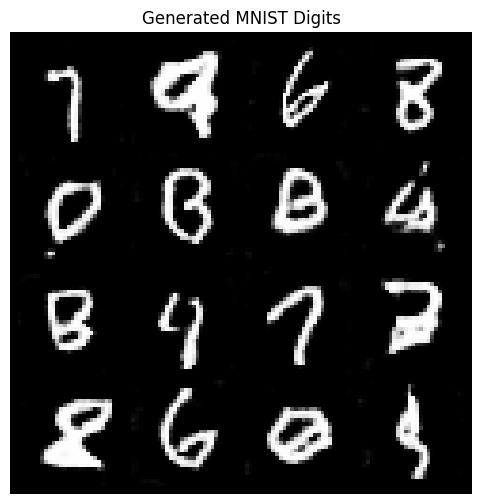

Saved 10 samples to generated_digits_10.png


In [10]:
G.eval()
with torch.no_grad():
    generated = G(fixed_noise).cpu()

generated = (generated + 1) / 2
grid = make_grid(generated, nrow=4, padding=2)

plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Generated MNIST Digits")
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap="gray")
plt.show()

save_image(generated[:10], "generated_digits_10.png", nrow=5)
print("Saved 10 samples to generated_digits_10.png")